# 3MD3220 — Reinforcement Learning: Individual Assignment
### Text Flappy Bird — Monte Carlo & Sarsa(λ)
**[Ton Prénom Nom]**

## 0. Setup

In [97]:
import sys
sys.path.insert(0, r"c:\Users\dadah\Downloads\text-flappy-bird-gym-master\text-flappy-bird-gym-master")
import text_flappy_bird_gym

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import text_flappy_bird_gym
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')



## 1. Environment

In [99]:
env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
obs, _ = env.reset()
print('Observation space:', env.observation_space)
print('Action space:', env.action_space)
print('Sample observation (dx, dy):', obs)

Observation space: Tuple(Discrete(14), Discrete(22, start=-11))
Action space: Discrete(2)
Sample observation (dx, dy): (13, 0)


## 3. Monte Carlo Agent (Every-Visit)

In [100]:
MAX_SCORE = 1000  # Remis à 1000 pour voir les vraies performances

def obs_to_state(obs):
    # Les observations de gymnasium changent de format -- faut les convertir en tuple hashable
    # sinon les dicts ne peuvent pas être utilisés comme clé dans le Q-table
    if isinstance(obs, dict):
        return tuple(sorted(obs.items()))
    elif isinstance(obs, np.ndarray):
        return tuple(obs.astype(int))
    else:
        return tuple(obs)

def epsilon_episode(ep, n_eps, eps_start=0.2, eps_end=0.01, decay=1000):
    # Explore beaucoup au début, exploite de plus en plus vers la fin
    return eps_end + (eps_start - eps_end) * np.exp(-ep / decay)

def greedy_action(Q, state):
    # Juste prendre le meilleur action connu
    if not isinstance(state, tuple):
        state = obs_to_state(state)
    return int(np.argmax(Q[state]))

def eps_greedy_action(Q, state, eps):
    # Avec probabilité eps on explore (aléatoire), sinon on exploite (greedy)
    if np.random.random() < eps:
        return env.action_space.sample()
    return greedy_action(Q, state)

def smooth(values, k=100):
    # Moyenne mobile pour lisser les graphes (sinon c'est trop bruyant)
    s = np.convolve(values, np.ones(k) / k, mode='valid')
    return s

def test_agent(get_action_fn, n_runs=100, env_kwargs=None):
    # Évalue l'agent en mode greedy (sans exploration) - teste vraiment ce qu'il a appris
    if env_kwargs is None:
        env_kwargs = {}
    
    env_test = gym.make('TextFlappyBird-v0', **env_kwargs)
    scores = []
    
    for _ in range(n_runs):
        obs, _ = env_test.reset()
        done = False
        score = 0
        
        while not done and score < MAX_SCORE:
            state = obs_to_state(obs)
            action = get_action_fn(state)
            obs, _, terminated, truncated, info = env_test.step(action)
            done = terminated or truncated
            score = info.get('score', score)
        
        scores.append(score)
    
    return np.array(scores)

In [101]:
print('Training Monte Carlo agent (5000 episodes)...')
Q_mc, mc_rewards, mc_scores = train_mc(n_episodes=5000, gamma=0.99, decay=1000)
print('Done.')

Training Monte Carlo agent (5000 episodes)...
Done.


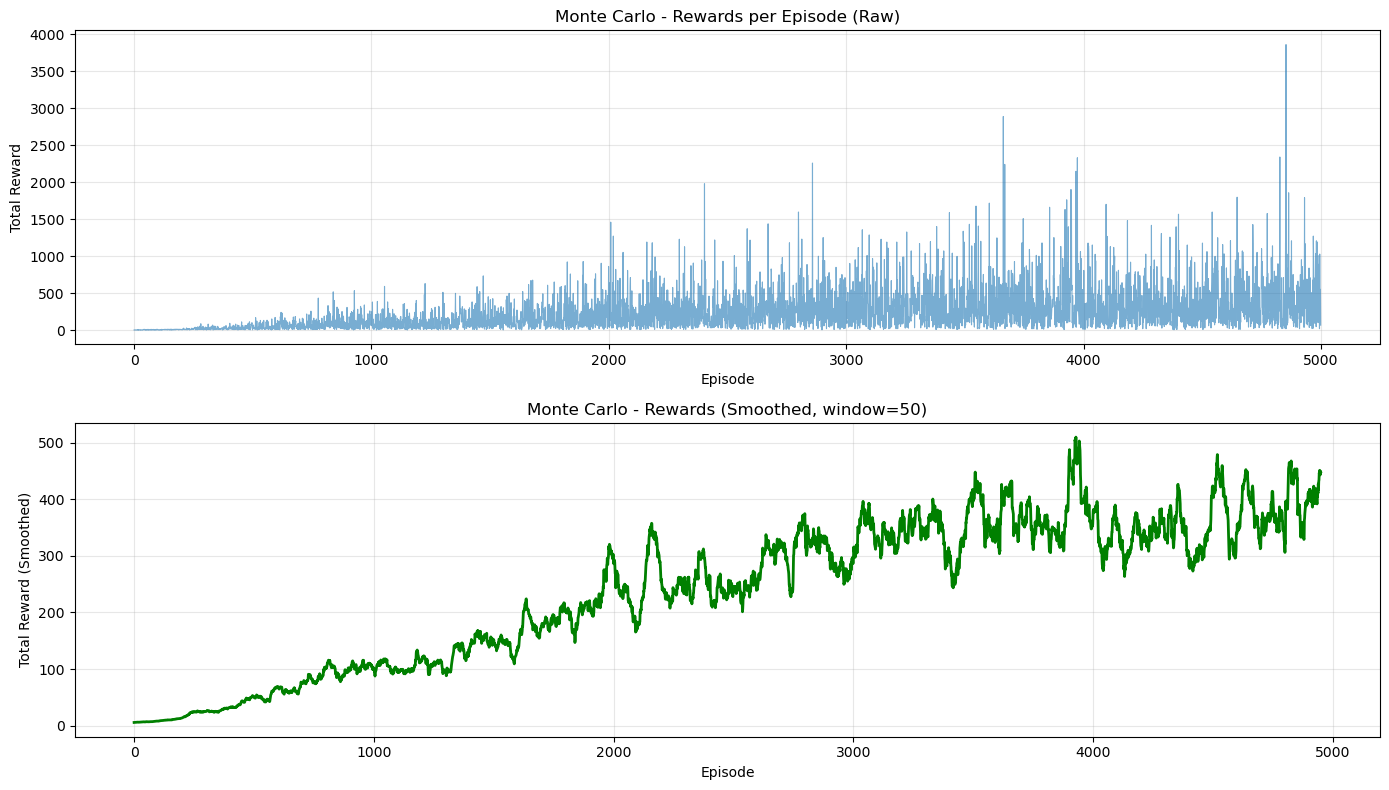


MONTE CARLO TRAINING STATISTICS
Episodes trained: 5000

Rewards:
  Mean: 237.93
  Std:  278.41
  Min:  4.00
  Max:  3863.00

Scores:
  Mean: 22.69
  Std:  27.84
  Min:  0.00
  Max:  385.00

Q-table states learned: 268


In [102]:

# Visualize training results
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Raw rewards over episodes
axes[0].plot(mc_rewards, alpha=0.6, linewidth=0.8)
axes[0].set_title('Monte Carlo - Rewards per Episode (Raw)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].grid(True, alpha=0.3)

# Plot 2: Smoothed rewards
k = 50
if len(mc_rewards) > k:
    smoothed_rewards = np.convolve(mc_rewards, np.ones(k)/k, mode='valid')
    axes[1].plot(smoothed_rewards, linewidth=2, color='green')
    axes[1].set_title(f'Monte Carlo - Rewards (Smoothed, window={k})')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Total Reward (Smoothed)')
    axes[1].grid(True, alpha=0.3)

# # Plot 3: Raw scores
# axes[1, 0].plot(mc_scores, alpha=0.6, linewidth=0.8)
# axes[1, 0].set_title('Monte Carlo - Scores per Episode (Raw)')
# axes[1, 0].set_xlabel('Episode')
# axes[1, 0].set_ylabel('Score')
# axes[1, 0].grid(True, alpha=0.3)

# # Plot 4: Smoothed scores
# if len(mc_scores) > k:
#     smoothed_scores = np.convolve(mc_scores, np.ones(k)/k, mode='valid')
#     axes[1, 1].plot(smoothed_scores, linewidth=2, color='orange')
#     axes[1, 1].set_title(f'Monte Carlo - Scores (Smoothed, window={k})')
#     axes[1, 1].set_xlabel('Episode')
#     axes[1, 1].set_ylabel('Score (Smoothed)')
#     axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*60)
print("MONTE CARLO TRAINING STATISTICS")
print("="*60)
print(f"Episodes trained: {len(mc_rewards)}")
print(f"\nRewards:")
print(f"  Mean: {np.mean(mc_rewards):.2f}")
print(f"  Std:  {np.std(mc_rewards):.2f}")
print(f"  Min:  {np.min(mc_rewards):.2f}")
print(f"  Max:  {np.max(mc_rewards):.2f}")
print(f"\nScores:")
print(f"  Mean: {np.mean(mc_scores):.2f}")
print(f"  Std:  {np.std(mc_scores):.2f}")
print(f"  Min:  {np.min(mc_scores):.2f}")
print(f"  Max:  {np.max(mc_scores):.2f}")
print(f"\nQ-table states learned: {len(dict(Q_mc))}")
print("="*60)

## 4. Sarsa(λ) Agent with Tile Coding

In [103]:
def train_mc(n_episodes=5000, gamma=0.99, decay=1000):
    """
    Monte Carlo Every-Visit
    Suis chaque trajectoire jusqu'à la fin, puis mets à jour les Q-values
    avec la moyenne des retours observés pour chaque (state, action)
    """
    env_mc = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
    
    # Le Q-table: Q[state][action] = valeur estimée
    Q = defaultdict(lambda: np.zeros(2))
    returns_sum = defaultdict(lambda: np.zeros(2))
    returns_count = defaultdict(lambda: np.zeros(2))
    
    rewards_history = []
    scores_history = []
    
    for ep in range(n_episodes):
        eps = epsilon_episode(ep, n_episodes, decay=decay)
        obs, _ = env_mc.reset()
        
        # Génère une trajectoire complète
        episode = []  # (state, action, reward)
        done = False
        total_reward = 0
        score = 0
        
        while not done and score < MAX_SCORE:
            state = obs_to_state(obs)
            action = eps_greedy_action(Q, state, eps)
            next_obs, reward, terminated, truncated, info = env_mc.step(action)
            done = terminated or truncated
            episode.append((state, action, reward))
            total_reward += reward
            score = info.get('score', score)
            obs = next_obs
        
        rewards_history.append(total_reward)
        scores_history.append(score)
        
        # MC update: parcours le chemin en arrière et accumule les retours
        G = 0
        for state, action, reward in reversed(episode):
            G = gamma * G + reward
            returns_sum[state][action] += G
            returns_count[state][action] += 1
            # Q = moyenne de tous les retours vus pour cette paire (s,a)
            Q[state][action] = returns_sum[state][action] / returns_count[state][action]
    
    return Q, rewards_history, scores_history

# Entrainement MC - prend un peu de temps...
print('Training Monte Carlo agent (5000 episodes)')
Q_mc, mc_rewards, mc_scores = train_mc(n_episodes=5000, gamma=0.99, decay=1000)



Training Monte Carlo agent (5000 episodes)


In [104]:
print('Training Sarsa(λ) agent (5 000 episodes)...')
w_sarsa, sarsa_rewards, sarsa_scores, NT, NTL = train_sarsa_lambda(
    n_episodes=5000, gamma=0.99, alpha=0.1, lam=0.9, decay=1000)
print('Done.')

Training Sarsa(λ) agent (5 000 episodes)...


100%|██████████| 5000/5000 [01:24<00:00, 59.41it/s] 

Done.


## 5. Pre-training comparison

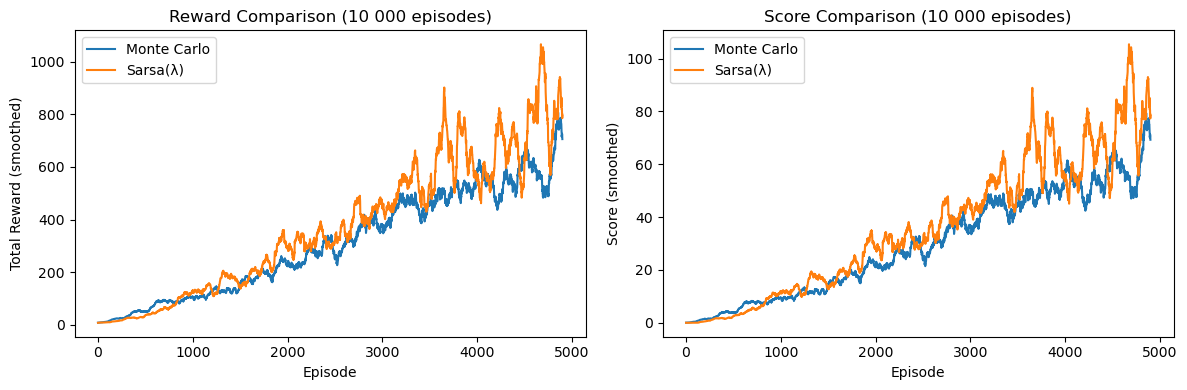

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

k = 100
axes[0].plot(smooth(mc_rewards, k), label='Monte Carlo')
axes[0].plot(smooth(sarsa_rewards, k), label='Sarsa(λ)')
axes[0].set_title('Reward Comparison (10 000 episodes)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward (smoothed)')
axes[0].legend()

axes[1].plot(smooth(mc_scores, k), label='Monte Carlo')
axes[1].plot(smooth(sarsa_scores, k), label='Sarsa(λ)')
axes[1].set_title('Score Comparison (10 000 episodes)')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Score (smoothed)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [106]:

mc_action_fn = lambda obs: greedy_action(Q_mc, obs)

def sarsa_action_fn(obs):
    state = obs_to_state(obs)
    tiles = tile_code(state, NT, NTL)
    qs = [sum(w_sarsa[t, a] for t in tiles) for a in range(2)]
    return int(np.argmax(qs))

# Test with debug info
def test_agent_debug(get_action_fn, n_runs=10, env_kwargs=None):
    """Evaluate agent with debug info."""
    if env_kwargs is None:
        env_kwargs = dict(height=15, width=20, pipe_gap=4)
    test_env = gym.make('TextFlappyBird-v0', **env_kwargs)
    scores = []
    for run in range(n_runs):
        obs, _ = test_env.reset()
        score = 0
        done = False
        steps = 0
        while not done and score < MAX_SCORE:
            action = get_action_fn(obs)
            obs, reward, terminated, truncated, info = test_env.step(action)
            done = terminated or truncated
            score = info.get('score', score)
            steps += 1
        scores.append(score)
        print(f"  Run {run+1}: score={score}, steps={steps}, done={done}")
    return scores

print("Testing Monte Carlo (first 5 runs with debug):")
mc_test_debug = test_agent_debug(mc_action_fn, n_runs=5)

print("\nTesting Sarsa(λ) (first 5 runs with debug):")
sarsa_test_debug = test_agent_debug(sarsa_action_fn, n_runs=5)

print("\n" + "="*60)
print("Full test (100 runs each):")
print("="*60)

mc_test  = test_agent(mc_action_fn, n_runs=100)
sarsa_test = test_agent(sarsa_action_fn, n_runs=100)

import pandas as pd
df = pd.DataFrame({'Monte Carlo': mc_test, 'Sarsa(λ)': sarsa_test})
print(df.describe().loc[['mean','std','min','50%','max']].rename(index={'50%':'median'}))

print(f"\nMC scores distribution:")
print(f"  Scores == 1000: {sum(1 for s in mc_test if s == 1000)}/{len(mc_test)}")
print(f"  Scores < 1000: {sum(1 for s in mc_test if s < 1000)}/{len(mc_test)}")

print(f"\nSarsa scores distribution:")
print(f"  Scores == 1000: {sum(1 for s in sarsa_test if s == 1000)}/{len(sarsa_test)}")
print(f"  Scores < 1000: {sum(1 for s in sarsa_test if s < 1000)}/{len(sarsa_test)}")

Testing Monte Carlo (first 5 runs with debug):
  Run 1: score=585, steps=5863, done=True
  Run 2: score=276, steps=2773, done=True
  Run 3: score=17, steps=183, done=True
  Run 4: score=95, steps=963, done=True
  Run 5: score=161, steps=1623, done=True

Testing Sarsa(λ) (first 5 runs with debug):
  Run 1: score=1000, steps=10004, done=False
  Run 2: score=1000, steps=10004, done=False
  Run 3: score=1000, steps=10004, done=False
  Run 4: score=1000, steps=10004, done=False
  Run 5: score=1000, steps=10004, done=False

Full test (100 runs each):
        Monte Carlo  Sarsa(λ)
mean     263.810000    1000.0
std      222.823284       0.0
min       11.000000    1000.0
median   204.500000    1000.0
max     1000.000000    1000.0

MC scores distribution:
  Scores == 1000: 2/100
  Scores < 1000: 98/100

Sarsa scores distribution:
  Scores == 1000: 100/100
  Scores < 1000: 0/100


In [107]:
print("Testing Monte Carlo (first 5 runs with debug):")
mc_test_debug = test_agent_debug(mc_action_fn, n_runs=5)

print("\nTesting Sarsa(λ) (first 5 runs with debug):")
sarsa_test_debug = test_agent_debug(sarsa_action_fn, n_runs=5)

print("\n" + "="*60)
print("Full test (100 runs each):")
print("="*60)

Testing Monte Carlo (first 5 runs with debug):
  Run 1: score=86, steps=873, done=True
  Run 2: score=480, steps=4813, done=True
  Run 3: score=319, steps=3203, done=True
  Run 4: score=470, steps=4713, done=True
  Run 5: score=87, steps=883, done=True

Testing Sarsa(λ) (first 5 runs with debug):
  Run 1: score=1000, steps=10004, done=False
  Run 2: score=1000, steps=10004, done=False
  Run 3: score=1000, steps=10004, done=False
  Run 4: score=1000, steps=10004, done=False
  Run 5: score=1000, steps=10004, done=False

Full test (100 runs each):


## 6. Q-function visualisation

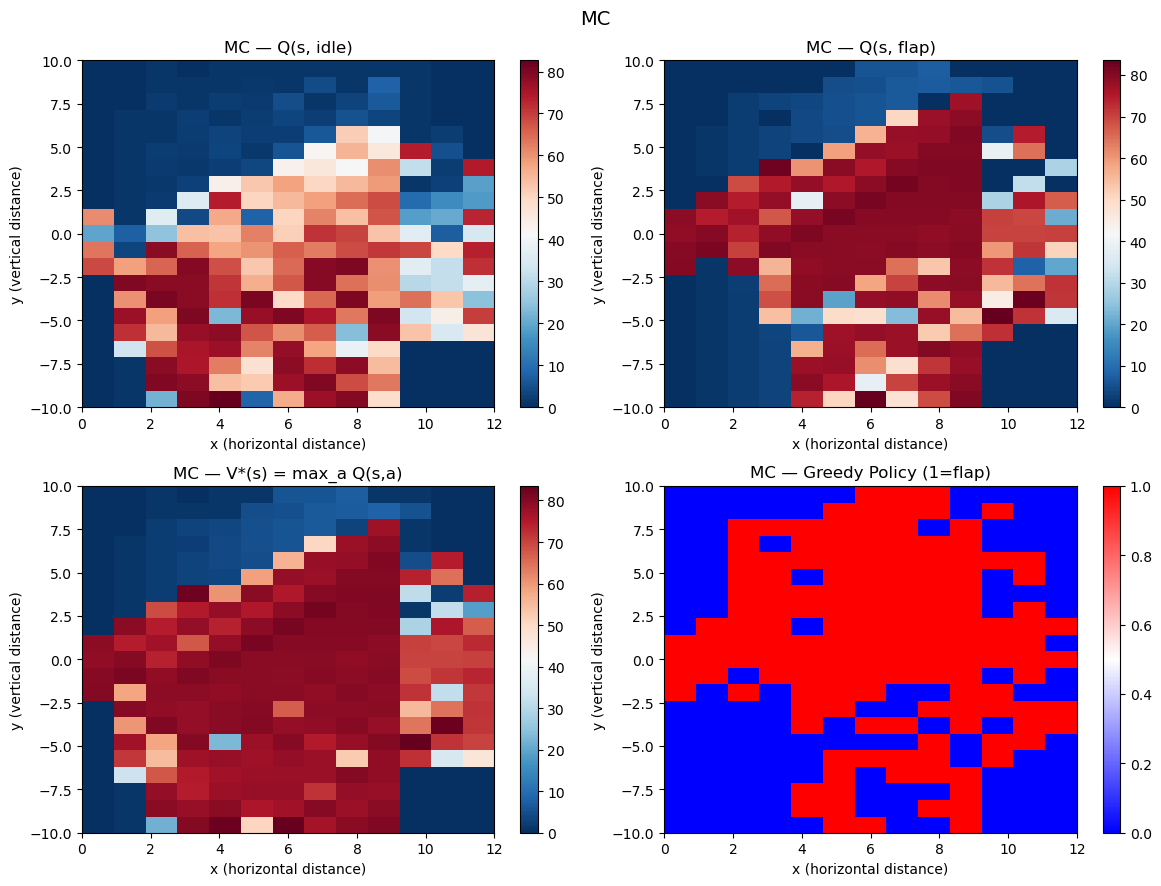

In [108]:
# Build a grid from the MC Q-table
x_range = range(0, 13)
y_range = range(-10, 11)

Q_idle   = np.zeros((len(y_range), len(x_range)))
Q_flap   = np.zeros((len(y_range), len(x_range)))
V_mc     = np.zeros((len(y_range), len(x_range)))
Policy_mc = np.zeros((len(y_range), len(x_range)))

for j, dy in enumerate(y_range):
    for i, dx in enumerate(x_range):
        state = (dx, dy)
        q = Q_mc[state]
        Q_idle[j, i]  = q[0]
        Q_flap[j, i]  = q[1]
        V_mc[j, i]    = max(q)
        Policy_mc[j, i] = int(np.argmax(q))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('MC', fontsize=14)

extent = [0, 12, -10, 10]
im0 = axes[0,0].imshow(Q_idle,  origin='lower', aspect='auto', cmap='RdBu_r', extent=extent)
axes[0,0].set_title('MC — Q(s, idle)')
axes[0,0].set_xlabel('x (horizontal distance)')
axes[0,0].set_ylabel('y (vertical distance)')
plt.colorbar(im0, ax=axes[0,0])

im1 = axes[0,1].imshow(Q_flap,  origin='lower', aspect='auto', cmap='RdBu_r', extent=extent)
axes[0,1].set_title('MC — Q(s, flap)')
axes[0,1].set_xlabel('x (horizontal distance)')
axes[0,1].set_ylabel('y (vertical distance)')
plt.colorbar(im1, ax=axes[0,1])

im2 = axes[1,0].imshow(V_mc,    origin='lower', aspect='auto', cmap='RdBu_r', extent=extent)
axes[1,0].set_title('MC — V*(s) = max_a Q(s,a)')
axes[1,0].set_xlabel('x (horizontal distance)')
axes[1,0].set_ylabel('y (vertical distance)')
plt.colorbar(im2, ax=axes[1,0])

im3 = axes[1,1].imshow(Policy_mc, origin='lower', aspect='auto', cmap='bwr', vmin=0, vmax=1, extent=extent)
axes[1,1].set_title('MC — Greedy Policy (1=flap)')
axes[1,1].set_xlabel('x (horizontal distance)')
axes[1,1].set_ylabel('y (vertical distance)')
plt.colorbar(im3, ax=axes[1,1])

plt.tight_layout()
plt.show()

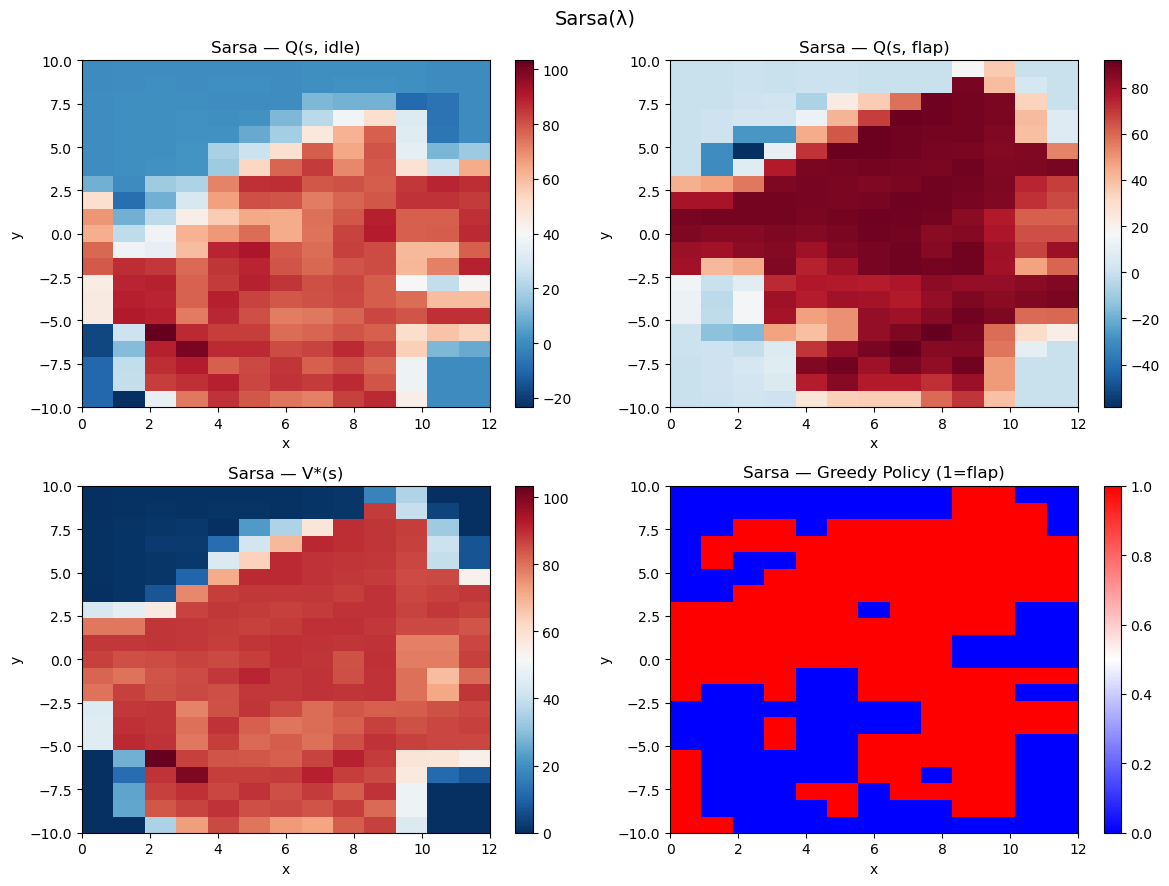

In [109]:
# Sarsa Q-function on the same grid (via weights)
Q_idle_s  = np.zeros((len(y_range), len(x_range)))
Q_flap_s  = np.zeros((len(y_range), len(x_range)))
V_sarsa   = np.zeros((len(y_range), len(x_range)))
Policy_s  = np.zeros((len(y_range), len(x_range)))

for j, dy in enumerate(y_range):
    for i, dx in enumerate(x_range):
        obs = (dx, dy)
        tiles = tile_code(obs, NT, NTL)
        q_idle = sum(w_sarsa[t, 0] for t in tiles)
        q_flap = sum(w_sarsa[t, 1] for t in tiles)
        Q_idle_s[j, i] = q_idle
        Q_flap_s[j, i] = q_flap
        V_sarsa[j, i]  = max(q_idle, q_flap)
        Policy_s[j, i] = int(q_flap > q_idle)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Sarsa(λ)', fontsize=14)

im0 = axes[0,0].imshow(Q_idle_s, origin='lower', aspect='auto', cmap='RdBu_r', extent=extent)
axes[0,0].set_title('Sarsa — Q(s, idle)')
axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel('y')
plt.colorbar(im0, ax=axes[0,0])

im1 = axes[0,1].imshow(Q_flap_s, origin='lower', aspect='auto', cmap='RdBu_r', extent=extent)
axes[0,1].set_title('Sarsa — Q(s, flap)')
axes[0,1].set_xlabel('x'); axes[0,1].set_ylabel('y')
plt.colorbar(im1, ax=axes[0,1])

im2 = axes[1,0].imshow(V_sarsa,  origin='lower', aspect='auto', cmap='RdBu_r', extent=extent)
axes[1,0].set_title('Sarsa — V*(s)')
axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel('y')
plt.colorbar(im2, ax=axes[1,0])

im3 = axes[1,1].imshow(Policy_s, origin='lower', aspect='auto', cmap='bwr', vmin=0, vmax=1, extent=extent)
axes[1,1].set_title('Sarsa — Greedy Policy (1=flap)')
axes[1,1].set_xlabel('x'); axes[1,1].set_ylabel('y')
plt.colorbar(im3, ax=axes[1,1])

plt.tight_layout()
plt.show()

## 7. Hyperparameter tuning

### 7.1 Epsilon decay

In [110]:
N_EP = 1000
decays = [N_EP, N_EP // 5, N_EP // 10]
decay_labels = [str(d) for d in decays]

# MC
mc_decay_train = []
mc_decay_test  = []
for d in decays:
    Q_, rw, _ = train_mc(n_episodes=N_EP, gamma=0.99, decay=d)
    mc_decay_train.append(rw)
    fn = lambda obs, Q=Q_: greedy_action(Q, tuple(obs))
    mc_decay_test.append(np.mean(test_agent(fn)))
    print(f'MC decay={d} → avg test reward={mc_decay_test[-1]:.0f}')

# Sarsa
sarsa_decay_train = []
sarsa_decay_test  = []
for d in decays:
    w_, rw, _, nt, ntl = train_sarsa_lambda(n_episodes=N_EP, decay=d)
    sarsa_decay_train.append(rw)
    def fn(obs, w=w_, nt=nt, ntl=ntl):
        tiles = tile_code(obs, nt, ntl)
        return int(np.argmax([sum(w[t,a] for t in tiles) for a in range(2)]))
    sarsa_decay_test.append(np.mean(test_agent(fn)))
    print(f'Sarsa decay={d} → avg test reward={sarsa_decay_test[-1]:.0f}')

MC decay=1000 → avg test reward=126
MC decay=200 → avg test reward=15
MC decay=100 → avg test reward=4


100%|██████████| 1000/1000 [00:03<00:00, 255.61it/s]


Sarsa decay=1000 → avg test reward=941


100%|██████████| 1000/1000 [00:00<00:00, 1261.93it/s]


Sarsa decay=200 → avg test reward=0


100%|██████████| 1000/1000 [00:00<00:00, 1303.54it/s]

Sarsa decay=100 → avg test reward=0


Parameters sensitivity

In [ ]:
# =============================================================
# Parameter Sensitivity — Monte Carlo agent
# =============================================================

# --- Effect of gamma ---
gammas = [0.5, 0.7, 0.9, 0.99]
gamma_scores = []

for g in tqdm.tqdm(gammas):
    Q_g, _, _ = train_mc(n_episodes=5000, gamma=g, decay=1000)
    fn = lambda obs, Q=Q_g: greedy_action(Q, tuple(obs))
    scores = test_agent(fn)
    gamma_scores.append(np.mean(scores))
    print(f'gamma={g} → mean test score={gamma_scores[-1]:.1f}')

# --- Effect of number of training episodes ---
n_episodes_list = [1000, 5000, 10000]
ep_scores = []

for n in tqdm.tqdm(n_episodes_list):
    Q_n, _, _ = train_mc(n_episodes=n, gamma=0.99, decay=1000)
    fn = lambda obs, Q=Q_n: greedy_action(Q, tuple(obs))
    scores = test_agent(fn)
    ep_scores.append(np.mean(scores))
    print(f'n_episodes={n} → mean test score={ep_scores[-1]:.1f}')


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([str(g) for g in gammas], gamma_scores)
axes[0].set_title('MC — Effect of γ on Test Score')
axes[0].set_xlabel('γ')
axes[0].set_ylabel('Average Test Score (100 runs)')

axes[1].bar([str(n) for n in n_episodes_list], ep_scores)
axes[1].set_title('MC — Effect of Training Episodes on Test Score')
axes[1].set_xlabel('Number of training episodes')
axes[1].set_ylabel('Average Test Score (100 runs)')

plt.tight_layout()
plt.savefig('sensitivity_sweep.png', dpi=150)
plt.show()

  0%|          | 0/4 [00:00<?, ?it/s]

Generalisation 

Retraining MC...
Retraining Sarsa...


100%|██████████| 10000/10000 [06:30<00:00, 25.63it/s]


Same config
(h15,w20,gap4) → MC: 911.6, Sarsa: 1000.0
Harder gap
(h15,w20,gap3) → MC: 0.7, Sarsa: 6.3
Larger world
(h20,w25,gap5) → MC: 0.0, Sarsa: 27.0


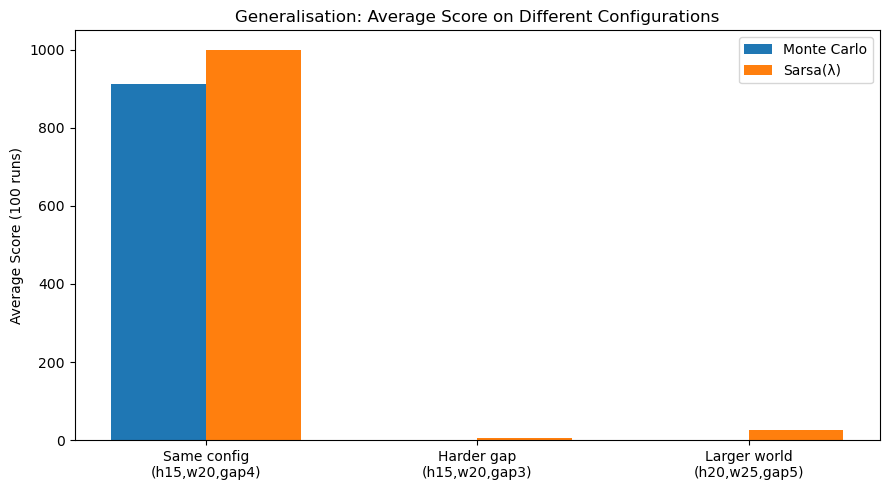

In [ ]:


configs = [
    ('Same config\n(h15,w20,gap4)', dict(height=15, width=20, pipe_gap=4)),
    ('Harder gap\n(h15,w20,gap3)', dict(height=15, width=20, pipe_gap=3)),
    ('Larger world\n(h20,w25,gap5)', dict(height=20, width=25, pipe_gap=5)),
]

# Retrain both agents with best params first
print('Retraining MC...')
Q_mc_best, _, _ = train_mc(n_episodes=10000, gamma=0.99, decay=1000)

print('Retraining Sarsa...')
w_best, _, _, NT_b, NTL_b = train_sarsa_lambda(
    n_episodes=10000, gamma=0.99, alpha=0.1, lam=0.9, decay=1000)

mc_action_best = lambda obs: greedy_action(Q_mc_best, tuple(obs))

def sarsa_action_best(obs):
    tiles = tile_code(obs, NT_b, NTL_b)
    return int(np.argmax([sum(w_best[t, a] for t in tiles) for a in range(2)]))

# Evaluate on each config
mc_gen    = []
sarsa_gen = []

for label, cfg in configs:
    mc_score    = np.mean(test_agent(mc_action_best,    env_kwargs=cfg))
    sarsa_score = np.mean(test_agent(sarsa_action_best, env_kwargs=cfg))
    mc_gen.append(mc_score)
    sarsa_gen.append(sarsa_score)
    print(f'{label.strip()} → MC: {mc_score:.1f}, Sarsa: {sarsa_score:.1f}')

# --- Plot ---
labels = [lbl for lbl, _ in configs]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, mc_gen,    width, label='Monte Carlo')
ax.bar(x + width/2, sarsa_gen, width, label='Sarsa(λ)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Generalisation: Average Score on Different Configurations')
ax.set_ylabel('Average Score (100 runs)')
ax.legend()
plt.tight_layout()
plt.savefig('generalisation.png', dpi=150)
plt.show()

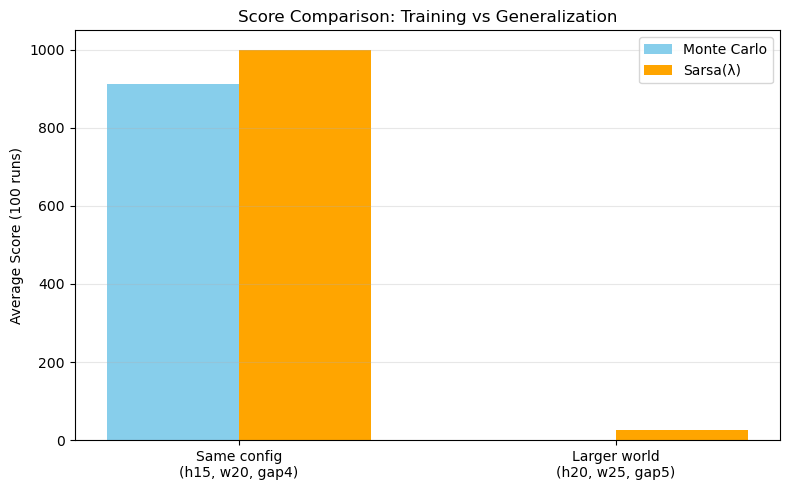


Score Comparison:
Config                         MC         Sarsa     
Same config                    911.6      1000.0    
Larger world                   0.0        27.0      


In [ ]:
# Simple comparison: Same config vs Larger world
fig, ax = plt.subplots(figsize=(8, 5))

configs_simple = ['Same config\n(h15, w20, gap4)', 'Larger world\n(h20, w25, gap5)']
x = np.arange(len(configs_simple))
width = 0.35

mc_scores_simple = [mc_gen[0], mc_gen[2]]
sarsa_scores_simple = [sarsa_gen[0], sarsa_gen[2]]

ax.bar(x - width/2, mc_scores_simple, width, label='Monte Carlo', color='skyblue')
ax.bar(x + width/2, sarsa_scores_simple, width, label='Sarsa(λ)', color='orange')

ax.set_ylabel('Average Score (100 runs)')
ax.set_title('Score Comparison: Training vs Generalization')
ax.set_xticks(x)
ax.set_xticklabels(configs_simple)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print the values
print("\nScore Comparison:")
print(f"{'Config':<30} {'MC':<10} {'Sarsa':<10}")
print("="*50)
print(f"{'Same config':<30} {mc_scores_simple[0]:<10.1f} {sarsa_scores_simple[0]:<10.1f}")
print(f"{'Larger world':<30} {mc_scores_simple[1]:<10.1f} {sarsa_scores_simple[1]:<10.1f}")